In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hey_transacciones.csv to hey_transacciones.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("hey_transacciones.csv")

df.head()

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,...,1,NaN,NaN,SPEI enviado,11,Sunday,False,app_android,False,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,1,NaN,5.69,dep. efvo,7,Saturday,False,app_ios,False,True


In [ ]:
df.columns

Index(['transaccion_id', 'user_id', 'producto_id', 'fecha_hora',
       'tipo_operacion', 'canal', 'monto', 'comercio_nombre', 'categoria_mcc',
       'ciudad_transaccion', 'estatus', 'motivo_no_procesada',
       'intento_numero', 'meses_diferidos', 'cashback_generado',
       'descripcion_libre', 'hora_del_dia', 'dia_semana', 'es_internacional',
       'dispositivo', 'patron_uso_atipico', 'es_dato_sintetico'],
      dtype='object')

In [ ]:
df.shape

(802384, 22)

In [ ]:
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"], errors="coerce")

df["monto"] = pd.to_numeric(df["monto"], errors="coerce").fillna(0)

df["cashback_generado"] = pd.to_numeric(df["cashback_generado"], errors="coerce").fillna(0)

df["meses_diferidos"] = pd.to_numeric(df["meses_diferidos"], errors="coerce").fillna(0)

df["motivo_no_procesada"] = df["motivo_no_procesada"].fillna("sin_motivo")
df["comercio_nombre"] = df["comercio_nombre"].fillna("sin_comercio")
df["descripcion_libre"] = df["descripcion_libre"].fillna("sin_descripcion")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802384 entries, 0 to 802383
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transaccion_id       802384 non-null  object        
 1   user_id              802384 non-null  object        
 2   producto_id          802384 non-null  object        
 3   fecha_hora           802384 non-null  datetime64[ns]
 4   tipo_operacion       802384 non-null  object        
 5   canal                802384 non-null  object        
 6   monto                802384 non-null  float64       
 7   comercio_nombre      802384 non-null  object        
 8   categoria_mcc        802384 non-null  object        
 9   ciudad_transaccion   783117 non-null  object        
 10  estatus              802384 non-null  object        
 11  motivo_no_procesada  802384 non-null  object        
 12  intento_numero       802384 non-null  int64         
 13  meses_diferido

In [ ]:
df["es_completada"] = (df["estatus"] == "completada").astype(int)
df["es_no_procesada"] = (df["estatus"] == "no_procesada").astype(int)
df["es_disputa"] = (df["estatus"] == "en_disputa").astype(int)
df["es_revertida"] = (df["estatus"] == "revertida").astype(int)

df["es_internacional_num"] = df["es_internacional"].astype(int)
df["es_atipica_num"] = df["patron_uso_atipico"].astype(int)

df.head()

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico,es_completada,es_no_procesada,es_disputa,es_revertida,es_internacional_num,es_atipica_num
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,True,app_ios,False,True,1,0,0,0,1,0
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,False,app_ios,False,True,1,0,0,0,0,0
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,False,app_huawei,False,True,1,0,0,0,0,0
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,sin_comercio,transferencia,CDMX - Benito Juárez,...,False,app_android,False,True,1,0,0,0,0,0
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,...,False,app_ios,False,True,1,0,0,0,0,0


In [ ]:
fecha_ref = df["fecha_hora"].max()

inicio_ultimos_30 = fecha_ref - pd.Timedelta(days=30)
inicio_previos_30 = fecha_ref - pd.Timedelta(days=60)

df["en_ultimos_30"] = (df["fecha_hora"] >= inicio_ultimos_30).astype(int)

df["en_previos_30"] = (
    (df["fecha_hora"] >= inicio_previos_30) &
    (df["fecha_hora"] < inicio_ultimos_30)
).astype(int)

fecha_ref

Timestamp('2025-12-15 13:59:36')

In [ ]:
def moda_segura(serie):
    serie = serie.dropna()
    if serie.empty:
        return "sin_dato"
    return serie.mode().iloc[0]

features = df.groupby("user_id").agg(
    total_transacciones=("transaccion_id", "count"),
    monto_total=("monto", "sum"),
    monto_promedio=("monto", "mean"),
    monto_maximo=("monto", "max"),

    transacciones_completadas=("es_completada", "sum"),
    transacciones_no_procesadas=("es_no_procesada", "sum"),
    transacciones_en_disputa=("es_disputa", "sum"),
    transacciones_revertidas=("es_revertida", "sum"),

    operaciones_internacionales=("es_internacional_num", "sum"),
    operaciones_atipicas=("es_atipica_num", "sum"),

    cashback_total=("cashback_generado", "sum"),
    meses_diferidos_promedio=("meses_diferidos", "mean"),

    ultima_transaccion=("fecha_hora", "max"),
    primera_transaccion=("fecha_hora", "min"),

    canal_principal=("canal", moda_segura),
    dispositivo_principal=("dispositivo", moda_segura),
    tipo_operacion_principal=("tipo_operacion", moda_segura),
    ciudad_principal=("ciudad_transaccion", moda_segura),
    categoria_principal=("categoria_mcc", moda_segura),

    canales_usados=("canal", "nunique"),
    productos_usados=("producto_id", "nunique"),
    comercios_usados=("comercio_nombre", "nunique"),
    tipos_operacion_usados=("tipo_operacion", "nunique"),

    transacciones_ultimos_30_dias=("en_ultimos_30", "sum"),
    transacciones_previos_30_dias=("en_previos_30", "sum")
).reset_index()

features.head()

,user_id,total_transacciones,monto_total,monto_promedio,monto_maximo,transacciones_completadas,transacciones_no_procesadas,transacciones_en_disputa,transacciones_revertidas,operaciones_internacionales,...,dispositivo_principal,tipo_operacion_principal,ciudad_principal,categoria_principal,canales_usados,productos_usados,comercios_usados,tipos_operacion_usados,transacciones_ultimos_30_dias,transacciones_previos_30_dias
0,USR-00001,56,119570.59,2135.189107,24010.0,53,3,0,0,2,...,app_android,compra,CDMX - Benito Juárez,servicios_digitales,6,2,24,8,2,5
1,USR-00002,74,212722.67,2874.630676,24830.0,71,1,1,1,1,...,app_android,compra,Puerto Vallarta,transferencia,6,2,29,7,3,6
2,USR-00003,79,190801.09,2415.203671,24540.0,71,4,3,1,4,...,app_android,compra,Cuauhtémoc,transferencia,8,2,31,9,3,10
3,USR-00004,66,580113.74,8789.602121,55000.0,61,2,2,1,2,...,app_android,compra,Guadalupe,transferencia,6,3,29,9,2,3
4,USR-00005,93,190277.30,2045.992473,24520.0,89,2,2,0,1,...,app_ios,compra,CDMX - Cuauhtémoc,transferencia,7,2,30,9,1,12


In [ ]:
features["tasa_no_procesadas"] = (
    features["transacciones_no_procesadas"] / features["total_transacciones"]
)

features["tasa_disputas"] = (
    features["transacciones_en_disputa"] / features["total_transacciones"]
)

features["tasa_reversos"] = (
    features["transacciones_revertidas"] / features["total_transacciones"]
)

features["tasa_internacional"] = (
    features["operaciones_internacionales"] / features["total_transacciones"]
)

features["dias_desde_ultima_transaccion"] = (
    fecha_ref - features["ultima_transaccion"]
).dt.days

features["variacion_actividad"] = (
    (features["transacciones_ultimos_30_dias"] - features["transacciones_previos_30_dias"]) /
    features["transacciones_previos_30_dias"].replace(0, np.nan)
).fillna(0)

features.head()

,user_id,total_transacciones,monto_total,monto_promedio,monto_maximo,transacciones_completadas,transacciones_no_procesadas,transacciones_en_disputa,transacciones_revertidas,operaciones_internacionales,...,comercios_usados,tipos_operacion_usados,transacciones_ultimos_30_dias,transacciones_previos_30_dias,tasa_no_procesadas,tasa_disputas,tasa_reversos,tasa_internacional,dias_desde_ultima_transaccion,variacion_actividad
0,USR-00001,56,119570.59,2135.189107,24010.0,53,3,0,0,2,...,24,8,2,5,0.053571,0.000000,0.000000,0.035714,23,-0.600000
1,USR-00002,74,212722.67,2874.630676,24830.0,71,1,1,1,1,...,29,7,3,6,0.013514,0.013514,0.013514,0.013514,18,-0.500000
2,USR-00003,79,190801.09,2415.203671,24540.0,71,4,3,1,4,...,31,9,3,10,0.050633,0.037975,0.012658,0.050633,20,-0.700000
3,USR-00004,66,580113.74,8789.602121,55000.0,61,2,2,1,2,...,29,9,2,3,0.030303,0.030303,0.015152,0.030303,19,-0.333333
4,USR-00005,93,190277.30,2045.992473,24520.0,89,2,2,0,1,...,30,9,1,12,0.021505,0.021505,0.000000,0.010753,29,-0.916667


In [ ]:
features["score_riesgo_transaccional"] = 0

features.loc[features["tasa_no_procesadas"] > 0.10, "score_riesgo_transaccional"] += 25
features.loc[features["tasa_disputas"] > 0.03, "score_riesgo_transaccional"] += 20
features.loc[features["tasa_reversos"] > 0.03, "score_riesgo_transaccional"] += 15
features.loc[features["variacion_actividad"] < -0.40, "score_riesgo_transaccional"] += 20
features.loc[features["operaciones_atipicas"] > 0, "score_riesgo_transaccional"] += 10
features.loc[features["dias_desde_ultima_transaccion"] > 30, "score_riesgo_transaccional"] += 10

features["score_riesgo_transaccional"] = features["score_riesgo_transaccional"].clip(0, 100)

In [ ]:
p80_monto = features["monto_total"].quantile(0.80)

features["score_oportunidad_transaccional"] = 0

features.loc[features["monto_total"] >= p80_monto, "score_oportunidad_transaccional"] += 25
features.loc[features["total_transacciones"] > 50, "score_oportunidad_transaccional"] += 20
features.loc[features["canal_principal"].isin(["app_ios", "app_android", "app_huawei"]), "score_oportunidad_transaccional"] += 15
features.loc[features["tipo_operacion_principal"].isin(["cargo_recurrente", "pago_servicio", "compra"]), "score_oportunidad_transaccional"] += 15
features.loc[features["cashback_total"] > 0, "score_oportunidad_transaccional"] += 10
features.loc[features["canales_usados"] >= 3, "score_oportunidad_transaccional"] += 10
features.loc[features["operaciones_internacionales"] > 0, "score_oportunidad_transaccional"] += 5

features["score_oportunidad_transaccional"] = features["score_oportunidad_transaccional"].clip(0, 100)

In [ ]:
def clasificar_nivel(score):
    if score >= 61:
        return "Alto"
    elif score >= 31:
        return "Medio"
    else:
        return "Bajo"

features["nivel_riesgo_transaccional"] = features["score_riesgo_transaccional"].apply(clasificar_nivel)
features["nivel_oportunidad_transaccional"] = features["score_oportunidad_transaccional"].apply(clasificar_nivel)

def generar_insight(row):
    if row["nivel_riesgo_transaccional"] == "Alto":
        return "Cliente con señales de fricción transaccional. Requiere atención preventiva."
    elif row["nivel_oportunidad_transaccional"] == "Alto":
        return "Cliente activo y con alto potencial comercial. Candidato a oferta personalizada."
    elif row["operaciones_atipicas"] > 0:
        return "Cliente con patrones atípicos. Conviene monitorear antes de recomendar productos."
    elif row["variacion_actividad"] < -0.40:
        return "Cliente con caída reciente de actividad. Conviene activar estrategia de retención."
    else:
        return "Cliente con comportamiento transaccional estable."

features["insight_transaccional"] = features.apply(generar_insight, axis=1)

features[[
    "user_id",
    "score_riesgo_transaccional",
    "nivel_riesgo_transaccional",
    "score_oportunidad_transaccional",
    "nivel_oportunidad_transaccional",
    "insight_transaccional"
]].head()

,user_id,score_riesgo_transaccional,nivel_riesgo_transaccional,score_oportunidad_transaccional,nivel_oportunidad_transaccional,insight_transaccional
0,USR-00001,20,Bajo,75,Alto,Cliente activo y con alto potencial comercial....
1,USR-00002,20,Bajo,75,Alto,Cliente activo y con alto potencial comercial....
2,USR-00003,40,Medio,75,Alto,Cliente activo y con alto potencial comercial....
3,USR-00004,20,Bajo,90,Alto,Cliente activo y con alto potencial comercial....
4,USR-00005,20,Bajo,75,Alto,Cliente activo y con alto potencial comercial....


In [ ]:
features.to_csv("transacciones_features_por_usuario.csv", index=False)

from google.colab import files
files.download("transacciones_features_por_usuario.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Total de transacciones:", len(df))
print("Total de usuarios:", df["user_id"].nunique())
print("Fecha inicial:", df["fecha_hora"].min())
print("Fecha final:", df["fecha_hora"].max())

print("\nEstatus de transacciones:")
print(df["estatus"].value_counts())

print("\nCanales principales:")
print(df["canal"].value_counts().head(10))

print("\nTipos de operación principales:")
print(df["tipo_operacion"].value_counts().head(10))

print("\nClientes por nivel de riesgo:")
print(features["nivel_riesgo_transaccional"].value_counts())

print("\nClientes por nivel de oportunidad:")
print(features["nivel_oportunidad_transaccional"].value_counts())

Total de transacciones: 802384
Total de usuarios: 15025
Fecha inicial: 2025-01-01 08:00:09
Fecha final: 2025-12-15 13:59:36

Estatus de transacciones:
estatus
completada      748267
no_procesada     26609
en_disputa       19033
revertida         8475
Name: count, dtype: int64

Canales principales:
canal
app_ios            268313
app_android        226431
pos_fisico         110411
app_huawei         105577
cajero_banregio     26526
codi                26354
oxxo                23152
cajero_externo      12463
farmacia_ahorro      3157
Name: count, dtype: int64

Tipos de operación principales:
tipo_operacion
compra              319524
transf_entrada       92167
transf_salida        90116
cargo_recurrente     67249
pago_credito         51651
pago_servicio        48562
abono_inversion      41769
retiro_cajero        38989
deposito_oxxo        23152
cashback             14226
Name: count, dtype: int64

Clientes por nivel de riesgo:
nivel_riesgo_transaccional
Bajo     10495
Medio     4237
Alt

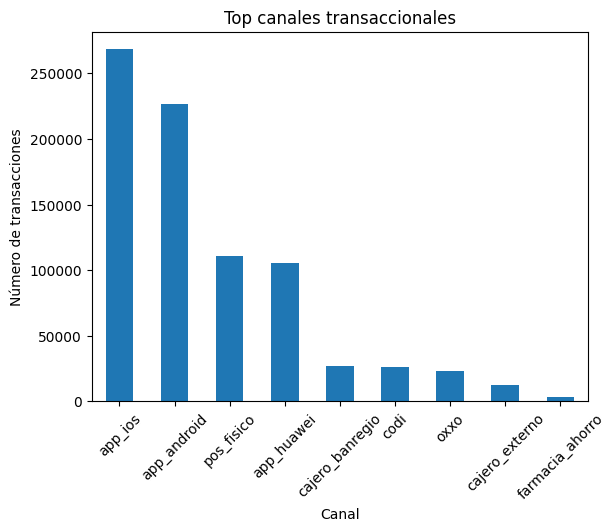

In [ ]:
import matplotlib.pyplot as plt

df["canal"].value_counts().head(10).plot(kind="bar")
plt.title("Top canales transaccionales")
plt.xlabel("Canal")
plt.ylabel("Número de transacciones")
plt.xticks(rotation=45)
plt.show()

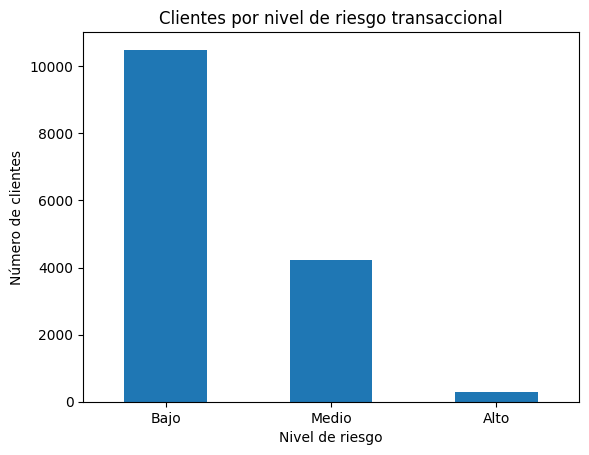

In [ ]:
features["nivel_riesgo_transaccional"].value_counts().plot(kind="bar")
plt.title("Clientes por nivel de riesgo transaccional")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()